# Introduction
The data hierarchy defines the coding methodology; where certain bits of code belong. First let's define the problem.

## Problem Description
We have a set of waveform data saved from an oscilloscope in a CSV format. The waveform represents the output of some circuit versus some input voltage. We need to plot the RMS output voltage vs. the RMS input voltage. The task is to read each waveform file, calculate the RMS voltage and store the result.

## Generate Surrogate Data
First we will generate surrogate data for this task. The following code generates a waveform and saves a file. We will go through the code bit by bit to explain what's happening.

In [1]:
import numpy as np
import pandas as pd
import os
###############
#     inputs
###############
# waveform parameters
f = 1e3                       # frequency
T = 1/f                       # Period
t = np.linspace(0,10*T,1000)  # time vector, 10 periods
gain = 2                      # gain of the circuit (Vout/Vin)

# save file parameters
saveLoc = './data/'                # save location
saveName = 'waveform_Vin-1.0.csv'   # save name

####################
#    Generate  and save data
####################
# create the save directory if it doesn't exist
if not os.path.exists(saveLoc):
    os.makedirs(saveLoc)   # this command fails if the directory exists already
Vin = 1.0                              # input RMS voltage
V = Vin*np.sqrt(2)*gain*np.sin(2*np.pi*f*t)       # output voltage

# save waveform
data = np.stack([t,V]).T   # combine t and V into one 2D array, first col is t and second is V
waveform = pd.DataFrame(data,columns=['Time','Voltage'])   # create pandas dataframe
waveform.to_csv(saveLoc+saveName,index=False)              # save to a file

We generate a time array that spans 10 periods of our sine wave at 1 kHz. Let's plot it to ensure it works.

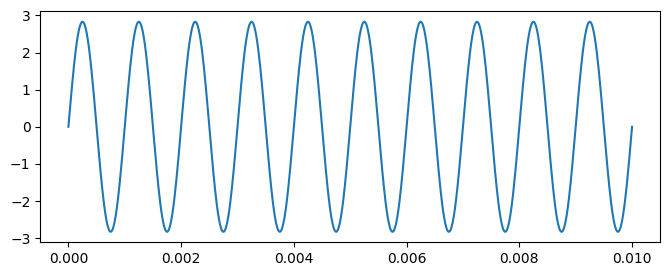

In [2]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(t,V)

The wave looks good. To save this data to a csv file, we utilize the pandas package. First we combine the time and voltage vector in to a 2D array with two columns. Then we create a pandas DataFrame and label the columns accordingly. The pandas DataFrame is like a spreadsheet for Python. It looks like the following:

In [3]:
print(waveform)

        Time       Voltage
0    0.00000  0.000000e+00
1    0.00001  1.777760e-01
2    0.00002  3.548489e-01
3    0.00003  5.305186e-01
4    0.00004  7.040904e-01
..       ...           ...
995  0.00996 -7.040904e-01
996  0.00997 -5.305186e-01
997  0.00998 -3.548489e-01
998  0.00999 -1.777760e-01
999  0.01000 -6.927648e-15

[1000 rows x 2 columns]


We have the index on the left, and two columns named Time and Voltage. Using the `to_csv()` function, we save the file to a csv. The `index=False` indicates not to save the index, because in this case it is not needed. The csv file is ASCI and contains 'comma separated values'. Open this file in a text editor and you will see this:

```
Time,Voltage
0.0,0.0
1.001001001001001e-05,0.06285329004448194
2.002002002002002e-05,0.12545803018029603
3.003003003003003e-05,0.1875666533758371
4.004004004004004e-05,0.2489335544668916
5.005005005005005e-05,0.3093160613888689
6.006006006006006e-05,0.3684753948102499
7.007007007007007e-05,0.42617761237243523
8.008008008008008e-05,0.4821945338020477
9.009009009009009e-05,0.5363046432373825
0.0001001001001001001,0.5882939652008051
0.0001101101101101101,0.6379569107531118
0.00012012012012012012,0.6850970904837808
0.00013013013013013012,0.7295280911221883
0.00014014014014014013,0.7710742126987246
0.00015015015015015014,0.809571163340744
```

Any spreadsheet program (most commonly Excell) can read this.

So now let's create a bunch of csv files with different amplitudes. Here we create 10 csv files.

In [4]:
import shutil
# define data generation function
def generate_data(saveloc):
    """Generate example data for the project
    This generates 10 csv files with time and voltage columns. Each file is
    tagged with a metastring, the input voltage is labeled in the filename
    
    Parameters
    ----------
    saveLoc : string
        path to save the data.
    """
    
    # waveform parameters
    f = 1e3                       # frequency
    T = 1/f                       # Period
    t = np.linspace(0,10*T,1000)  # time vector, 10 periods
    gain = 2                      # gain of the circuit (Vout/Vin)
    
    
    # delete the contents of the folder if it exists
    if os.path.exists(saveloc):
        shutil.rmtree(saveloc)  # this command fails if directory doesn't exist
    # create the save directory if it doesn't exist
    if not os.path.exists(saveloc):
        os.makedirs(saveloc)    # this command fails if the directory exists already
        
    Vins = np.linspace(1,10,10)
    for Vin in Vins:
        Vnew = Vin*np.sqrt(2)*gain*np.sin(2*np.pi*f*t)       # output voltage
        
        # save waveform
        savename = 'waveform_Vin-%0.1f.csv'%Vin   # save name defining Vin by the dmanage naming convention
        data = np.stack([t,Vnew]).T   # combine t and V into one 2D array, first col is t and second is V
        waveform = pd.DataFrame(data,columns=['Time','Voltage'])   # create pandas dataframe
        waveform.to_csv(saveloc+savename,index=False)              # save to a file
    return 
    
generate_data(saveLoc)             # generate data

The 10 csv files are in the data directory. Using the `tree` command from a terminal, shows the files.
 
```console
$ tree
.
├── waveform_Vin-10.0.csv
├── waveform_Vin-1.0.csv
├── waveform_Vin-2.0.csv
├── waveform_Vin-3.0.csv
├── waveform_Vin-4.0.csv
├── waveform_Vin-5.0.csv
├── waveform_Vin-6.0.csv
├── waveform_Vin-7.0.csv
├── waveform_Vin-8.0.csv
└── waveform_Vin-9.0.csv

0 directories, 10 files
```

The input voltage Vin is defined in the name by the naming conventions defined here. Now we want to read all these files and calculate the RMS voltage

## Traditional Approach
The traditional approach is to read a file, calculate the RMS, store the result, loop through all files, plot the result. Also, Let's pretend we did not just generate the data, all we have is the data in the data directory.

['waveform_Vin-6.0.csv', 'waveform_Vin-3.0.csv', 'waveform_Vin-8.0.csv', 'waveform_Vin-4.0.csv', 'waveform_Vin-1.0.csv', 'waveform_Vin-5.0.csv', 'waveform_Vin-7.0.csv', 'waveform_Vin-10.0.csv', 'waveform_Vin-9.0.csv', 'waveform_Vin-2.0.csv']
['waveform_Vin-1.0.csv', 'waveform_Vin-10.0.csv', 'waveform_Vin-2.0.csv', 'waveform_Vin-3.0.csv', 'waveform_Vin-4.0.csv', 'waveform_Vin-5.0.csv', 'waveform_Vin-6.0.csv', 'waveform_Vin-7.0.csv', 'waveform_Vin-8.0.csv', 'waveform_Vin-9.0.csv']
['waveform_Vin-1.0.csv', 'waveform_Vin-2.0.csv', 'waveform_Vin-3.0.csv', 'waveform_Vin-4.0.csv', 'waveform_Vin-5.0.csv', 'waveform_Vin-6.0.csv', 'waveform_Vin-7.0.csv', 'waveform_Vin-8.0.csv', 'waveform_Vin-9.0.csv', 'waveform_Vin-10.0.csv']


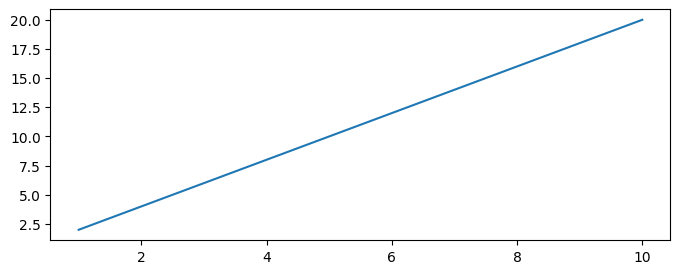

In [5]:
from pathlib import Path # used to remove extension from filename

# find all the folders in the data directory and store in a list
filenames = os.listdir(saveLoc)

# sort the filenames in correct order
print(filenames)           # the filenames are not sorted in alphanumeric order
print(sorted(filenames))   # the Vin-10.0 follows Vin-1.0, not desirable
import natsort
print(natsort.natsorted(filenames))   # This sorts in the desired order
filenames = natsort.natsorted(filenames)

# read through the files
Vrms = np.zeros(len(filenames))
Vin = np.zeros(len(filenames))
for i,filename in enumerate(filenames):
    df = pd.read_csv(saveLoc + filename)
    Vrms[i] = np.sqrt((df['Voltage']**2).mean())
    Vin[i] = float(Path(filename).stem.split('_')[-1].split('-')[-1])   # extract the input voltage from the filename
fig = plt.figure(1, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(Vin,Vrms)

So we have successfully read through each file, calculated the RMS voltage, read the input voltage from the filename, and plotted the result.

This approach works but is not very robust or scalable. In this example we explicitly extracted the input voltage from the filename with this command `Vin[i] = float(Path(filename).stem.split('_')[-1].split('-')[-1])`, if we want to read another data folder with a different filename, we'd have to create a new command. Also, this detects and reads every file in the folder, if some other file is in the directory, it would crash. Let's test this.

In [6]:
with open(os.path.join(saveLoc, 'randomFile.txt'), 'w') as temp_file:
    temp_file.write('This is an extra file that might be important information about the dataset')

filenames = os.listdir(saveLoc)
filenames = natsort.natsorted(filenames)
print(filenames)

['randomFile.txt', 'waveform_Vin-1.0.csv', 'waveform_Vin-2.0.csv', 'waveform_Vin-3.0.csv', 'waveform_Vin-4.0.csv', 'waveform_Vin-5.0.csv', 'waveform_Vin-6.0.csv', 'waveform_Vin-7.0.csv', 'waveform_Vin-8.0.csv', 'waveform_Vin-9.0.csv', 'waveform_Vin-10.0.csv']


In [7]:
# read through the files
Vrms = np.zeros(len(filenames))
Vin = np.zeros(len(filenames))
for i,filename in enumerate(filenames):
    df = pd.read_csv(saveLoc + filename)
    print(df)                                    # this DataFrame just has the contents of random.txt
    Vrms[i] = np.sqrt((df['Voltage']**2).mean())
    Vin[i] = float(Path(filename).stem.split('_')[-1].split('-')[-1])   # extract the input voltage from the filename

Empty DataFrame
Columns: [This is an extra file that might be important information about the dataset]
Index: []


KeyError: 'Voltage'

Having this random file here crashes our script. To solve this we can add checks to make the script more robust. But this is a pain, and this is why dmanage exists! Let's follow the D/Manage methodology so reading a group of files is **easy**!

## Data Hierarchy Approach
Here we setup the hierarchical approach used by dmanage under the hood. We create a DataUnit and DataGroup classes/levels. The component levels are ignored for simplicity; there is only one component, waveforms, so components are not really necessary.

In [ ]:

class DataFile():
    def __init__(self,filepath):
        # this gets all the information about the data unit
        self.dataFile = filepath
        
    def is_valid(self,dataFile):
        # this checks the validity of the file
        return ('.csv' in dataFile)
    
    def read_waveform(self):
        df = pd.read_csv(self.dataFile)
        df = df.set_index('Time')
        return df
        
    def parse_filename(self):
        return float(Path(self.dataFile).stem.split('_')[-1].split('-')[-1])
        
    def get_waveform_rms(self):
        df = self.read_waveform()
        return np.sqrt((df['Voltage']**2).mean())

class DataDirectory(DataFile):
    def __init__(self,filepath):
        # this gets all information about the data units
        self.baseDir = os.path.join(filepath,'')
        self.dataUnits = self.get_datafiles(filepath)
        
    def get_datafiles(self,folder):
        # this finds all valid data units
        # it uses the parent method is_valid
        allFiles = os.listdir(folder)
        allFiles = natsort.natsorted(allFiles)
        filenames = []
        for file in allFiles:
            if self.is_valid(file):
                filenames = filenames + [file]
        return filenames

    def get_waveform_rms(self):
        # This seteps through each data unit, instantiates a DataFile object, and 
        # reads the RMS value of that class
        values = []
        for dataUnit in self.dataUnits:
            D = DataFile(self.baseDir + dataUnit)
            values = values + [D.get_waveform_rms()]
        #df = pd.concat(dfs)
        return values

    def parse_filename(self):
        # This seteps through each data unit, instantiates a DataFile object, and 
        # reads the RMS value of that class
        values = []
        for dataUnit in self.dataUnits:
            D = DataFile(self.baseDir + dataUnit)
            values = values + [D.parse_filename()]
        return values

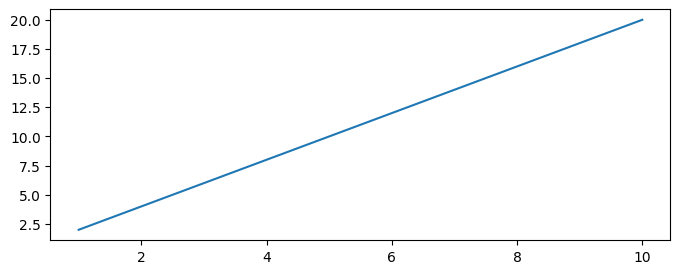

In [36]:
dataDir = saveLoc
DD = DataDirectory(dataDir)
Vrms = DD.get_waveform_rms()
Vin = DD.parse_filename()
fig = plt.figure(1, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(Vin,Vrms)

It worked. This is a lot of code to do something relatively simple, but this methodology offers benefits in return. The DataFile object contains all the information about the data unit. In this case only the filename is needed, but with more complicated data units, this would be helpful. The DataDir object contains everything you need to know about the data units in the directory. In this case, only the base directory and the filenames are needed, but with more complicated data units, this is nice to have. All the methods of the DataDir class basically steps through each unit, instantiates the DataFile class, and runs the appropriate code. The same code is used over and over again, so this could be streamlined... And it is, in the dmanage package.

## D-Manage Approach
Here it is:

In [ ]:
from dmanage.group import make_data_group
from dmanage.unit import make_data_unit
from dmanage.decorate import override
from dmanage.metadata.metastring import parse

DataUnit = make_data_unit()
class DataFile(DataUnit):
    def __init__(self,filepath):
        self.dataFile = filepath
    def is_valid(self,dataFile):
        return ('.csv' in dataFile)
    # child_override instructs the DataDirectory class to override the method with parallelly 
    # looped method to step through each data unit
    @override()
    def read_waveform(self):
        df = pd.read_csv(self.dataFile)
        df = df.set_index('Time')
        return df
    # no override here because dmanage.metadata.parser.parse_filename concats the result where 
    def parse_filename(self):
        return parse(self.dataFile, 'Vin')
        
    @override()
    def get_waveform_rms(self):
        df = self.read_waveform()
        return np.sqrt((df['Voltage']**2).mean())


DataDir = make_data_group(DataFile)
class DataDirectory(DataDir):
    """
    Data Directory class that reads all csv waveform files in a directory and gives access
    to wrapped DataFile class methods. Each method in the DataFile class is wrapped with the
    parallelize_iterator_method to step through all detected waveform files

    The attribute self.dataUnits contains a list of all valid csv files
    """
    # This overrides the DataFile method and uses the DataDir self.dataUnits Parameter
    def parse_filename(self):
        return parse(self.dataUnits, 'Vin')  # We utilize the self.dataUnits attribute here instead

In [ ]:
filename = './data/waveform_Vin-1.0.csv'
D = DataFile(filename)
waveform = D.read_waveform()
print(waveform)

In [ ]:
dataDir = saveLoc
DD = DataDirectory(dataDir,dataUnitType='file')
Vrms = DD.get_waveform_rms()
Vin = DD.parse_filename()

fig = plt.figure(1, figsize=(8,3))
ax = fig.subplots(nrows=1,ncols=1)
ax.plot(Vin,Vrms)

The hierarchy did everything for you! that's what the dmanage_ inheritance does for you. the DataGroup class wraps all DataUnit level methods with a for loop that steps through all valid data files. It also wraps the methods with a parallel implementation, so it can also read the data parallely by setting the `nc` arg greater than 1.

**_NOTE_** reading from the drive parallely is only faster on solid state drives (SSDs). Reading parallely from hard drives is slower due to the nature of the HD mechanism! This limitation may be overcome with development of pipelining (not developed yet). Also, reading parallely from the SSD drive might be also be improved by someone smarter than me; I just launch a pool that all read from drive at the same time and hope that it's faster and it turns out it is... for SSDs

We can also read all the waveforms and have access to them on the data group level.

In [ ]:
waveforms = DD.read_waveform()
print('waveforms is a list of length %i'%(len(waveforms)))
print('The First two elements look like:\n%s'%(waveforms[0:2]))